# Netflix Content Intelligence – Exploratory Data Analysis


## 1.Import Libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Netflix EDA Environment Ready!")

Netflix EDA Environment Ready!


## 2. Load Dataset

In [31]:
df = pd.read_csv("../data/netflix_titles.csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 3. Dataset Overview

In [32]:


print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Number of rows: 8807
Number of columns: 12

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


## 4. Missing Values Analysis

In [33]:
missing_values = df.isnull().sum()

print(missing_values)

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


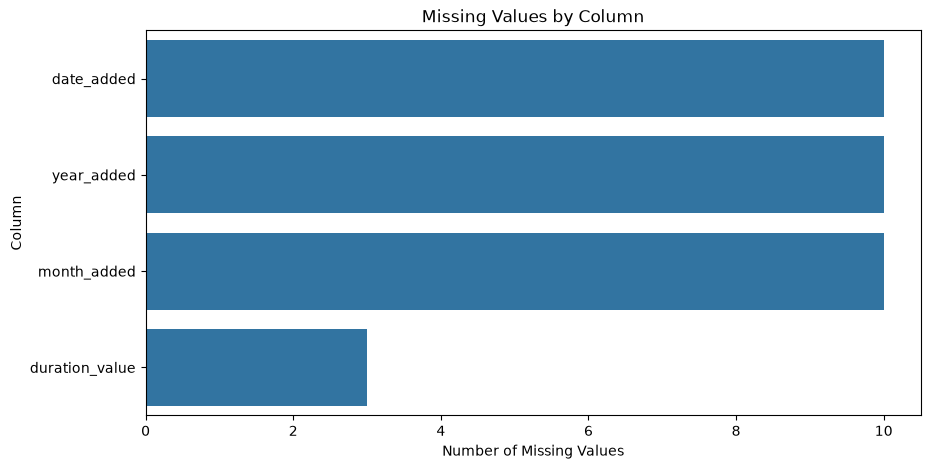

In [90]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing.values,
    y=missing.index
)

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")

plt.show()

## 5. Duplicate Analysis

In [35]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


In [36]:
# Duplicate percentage

duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate percentage: 0.00%


In [37]:
# Check for duplicate show IDs

duplicate_show_ids = df["show_id"].duplicated().sum()

print("Duplicate show IDs:", duplicate_show_ids)

Duplicate show IDs: 0


## 6. Data Cleaning

In [38]:
# Handle missing values in text columns

df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

print("Text columns cleaned successfully!")

Text columns cleaned successfully!


In [39]:
# Check remaining missing values

df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64

In [40]:
# Check the original date values that could not be converted

df[df["date_added"].isna()][["title", "date_added"]].head(20)

,title,date_added
6066,A Young Doctor's Notebook and Other Stories,NaN
6174,Anthony Bourdain: Parts Unknown,NaN
6795,Frasier,NaN
6806,Friends,NaN
6901,Gunslinger Girl,NaN
7196,Kikoriki,NaN
7254,La Familia P. Luche,NaN
7406,Maron,NaN
7847,Red vs. Blue,NaN
8182,The Adventures of Figaro Pho,NaN


In [41]:
# Reload original data to inspect date_added values

original_df = pd.read_csv("../data/netflix_titles.csv")

print("Original missing dates:", original_df["date_added"].isna().sum())
print("\nSample date values:")
print(original_df["date_added"].dropna().head(10))

Original missing dates: 10

Sample date values:
0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
5    September 24, 2021
6    September 24, 2021
7    September 24, 2021
8    September 24, 2021
9    September 24, 2021
Name: date_added, dtype: str


In [42]:
# Reload the original dataset

df = pd.read_csv("../data/netflix_titles.csv")

print("Dataset restored:", df.shape)

Dataset restored: (8807, 12)


In [43]:
# Handle missing text values

df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

print("Text columns cleaned successfully!")

Text columns cleaned successfully!


In [44]:
# Convert date_added to datetime

df["date_added"] = pd.to_datetime(
    df["date_added"],
    format="%B %d, %Y",
    errors="coerce"
)

print("Missing dates after conversion:", df["date_added"].isna().sum())

Missing dates after conversion: 98


In [ ]:
# Find date values that pandas cannot parse

test_dates = pd.to_datetime(
    original_df["date_added"],
    errors="coerce"
)

failed_dates = original_df.loc[
    original_df["date_added"].notna() & test_dates.isna(),
    "date_added"
]

print("Number of unparseable dates:", len(failed_dates))
print("\nUnparseable date values:")
print(failed_dates.value_counts().head(30))

Number of unparseable dates: 88

Unparseable date values:
date_added
July 1, 2017         4
August 4, 2017       3
February 1, 2019     3
January 1, 2018      3
November 1, 2017     3
November 1, 2019     2
October 1, 2019      2
December 15, 2017    2
March 31, 2018       2
December 14, 2018    2
July 20, 2018        2
November 1, 2016     2
December 1, 2019     2
June 1, 2017         2
December 23, 2018    1
December 15, 2018    1
July 26, 2019        1
May 26, 2016         1
December 2, 2017     1
March 15, 2019       1
April 4, 2017        1
December 28, 2016    1
February 24, 2018    1
January 17, 2018     1
September 7, 2016    1
October 31, 2018     1
August 21, 2017      1
October 8, 2013      1
December 1, 2018     1
March 16, 2016       1
Name: count, dtype: int64


In [46]:
# Check the data types and exact formatting of the problematic dates

print(failed_dates.head(20).tolist())

[' August 4, 2017', ' December 23, 2018', ' December 15, 2018', ' July 1, 2017', ' July 26, 2019', ' May 26, 2016', ' November 1, 2019', ' December 2, 2017', ' March 15, 2019', ' October 1, 2019', ' December 15, 2017', ' July 1, 2017', ' August 4, 2017', ' April 4, 2017', ' December 28, 2016', ' March 31, 2018', ' February 1, 2019', ' January 1, 2018', ' July 1, 2017', ' February 24, 2018']


In [47]:
# Remove leading and trailing spaces from date values

df = original_df.copy()

df["date_added"] = df["date_added"].str.strip()

print(df["date_added"].dropna().head())

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
Name: date_added, dtype: str


In [48]:
# Convert cleaned dates to datetime

df["date_added"] = pd.to_datetime(
    df["date_added"],
    format="%B %d, %Y",
    errors="coerce"
)

print("Missing dates after conversion:", df["date_added"].isna().sum())

Missing dates after conversion: 10


In [49]:
# Inspect missing ratings

missing_ratings = df[df["rating"].isna()]

print("Missing ratings:", len(missing_ratings))
print(missing_ratings[["title", "type", "rating"]])

Missing ratings: 4
                                                  title     type rating
5989  13TH: A Conversation with Oprah Winfrey & Ava ...    Movie    NaN
6827                  Gargantia on the Verdurous Planet  TV Show    NaN
7312                                       Little Lunch  TV Show    NaN
7537                               My Honor Was Loyalty    Movie    NaN


In [50]:
# Handle missing ratings

df["rating"] = df["rating"].fillna("Unknown")

print("Missing ratings after cleaning:", df["rating"].isna().sum())

Missing ratings after cleaning: 0


In [51]:
# Inspect missing duration values

missing_duration = df[df["duration"].isna()]

print("Missing durations:", len(missing_duration))
print(missing_duration[["title", "type", "duration"]])

Missing durations: 3
                                     title   type duration
5541                       Louis C.K. 2017  Movie      NaN
5794                 Louis C.K.: Hilarious  Movie      NaN
5813  Louis C.K.: Live at the Comedy Store  Movie      NaN


In [52]:
# Handle missing duration values

df["duration"] = df["duration"].fillna("Unknown")

print("Missing durations after cleaning:", df["duration"].isna().sum())

Missing durations after cleaning: 0


In [54]:
# Final missing-value check
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64

In [55]:
# Finalize all missing-value cleaning

# Text columns
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

# Rating and duration
df["rating"] = df["rating"].fillna("Unknown")
df["duration"] = df["duration"].fillna("Unknown")

# Final check
print("Final missing-value check:")
print(df.isnull().sum())

Final missing-value check:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


## 7. Feature Engineering

In [56]:
# Feature Engineering: Extract year and month

df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

print(df[["date_added", "year_added", "month_added"]].head())

  date_added  year_added  month_added
0 2021-09-25      2021.0          9.0
1 2021-09-24      2021.0          9.0
2 2021-09-24      2021.0          9.0
3 2021-09-24      2021.0          9.0
4 2021-09-24      2021.0          9.0


## 8. Univariate Analysis

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


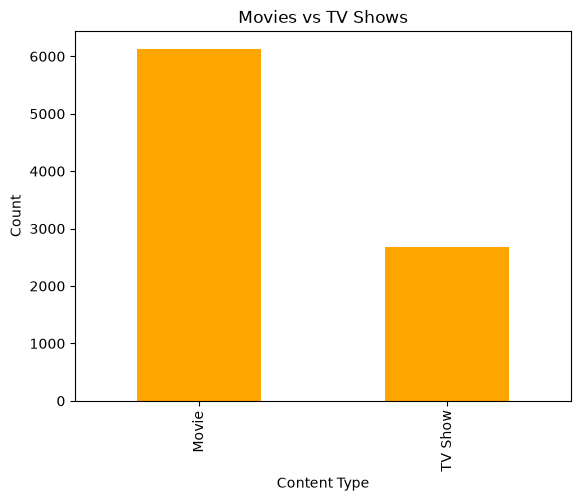

In [69]:
# Univariate Analysis: Content Type Distribution

type_counts = df["type"].value_counts()

print(type_counts)

type_counts.plot(
    kind="bar",
    color="orange"
)

plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


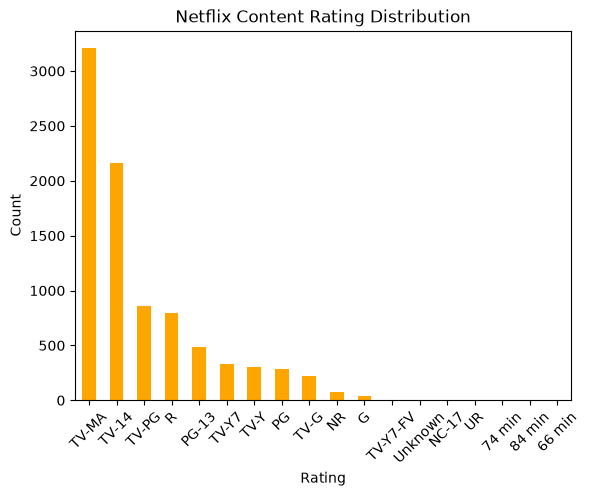

In [68]:
# Univariate Analysis: Rating Distribution

rating_counts = df["rating"].value_counts()

print(rating_counts)

rating_counts.plot(
    kind="bar",
    color="orange"
)

plt.title("Netflix Content Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

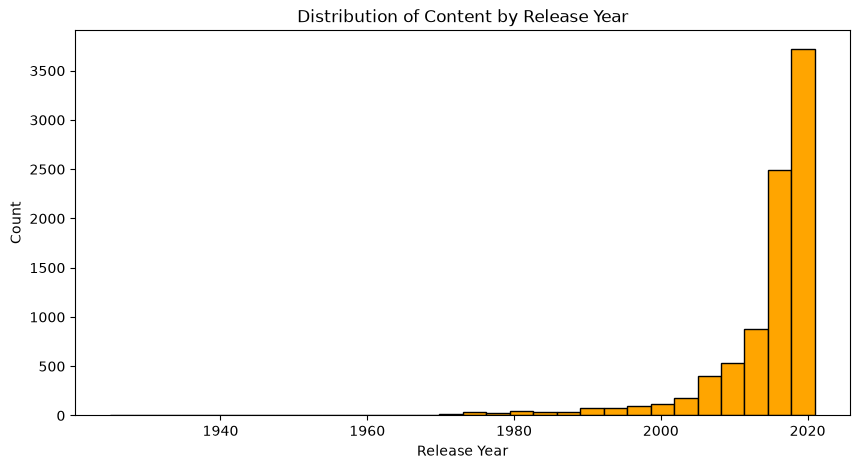

In [71]:
# Univariate Analysis: Release Year Distribution

plt.figure(figsize=(10, 5))

df["release_year"].plot(
    kind="hist",
    bins=30,
    color="orange",
    edgecolor="black"
)

plt.title("Distribution of Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()

## 9. Bivariate Analysis

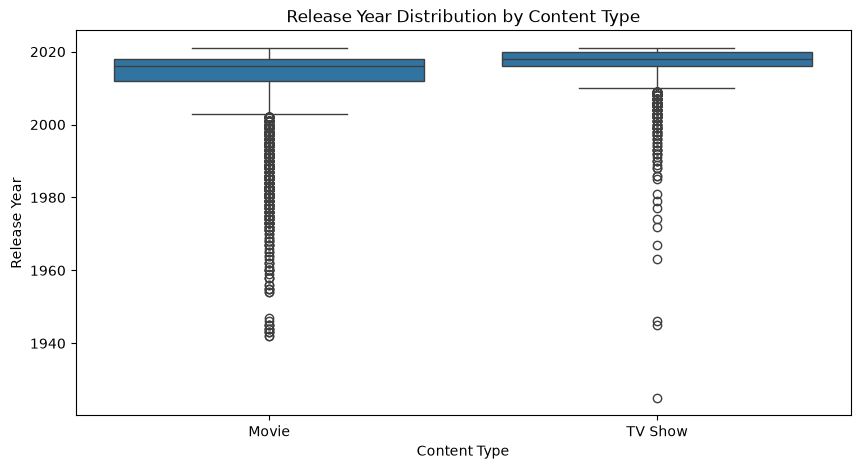

In [73]:
# Bivariate Analysis: Content Type vs Release Year

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="type",
    y="release_year"
)

plt.title("Release Year Distribution by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Release Year")
plt.show()

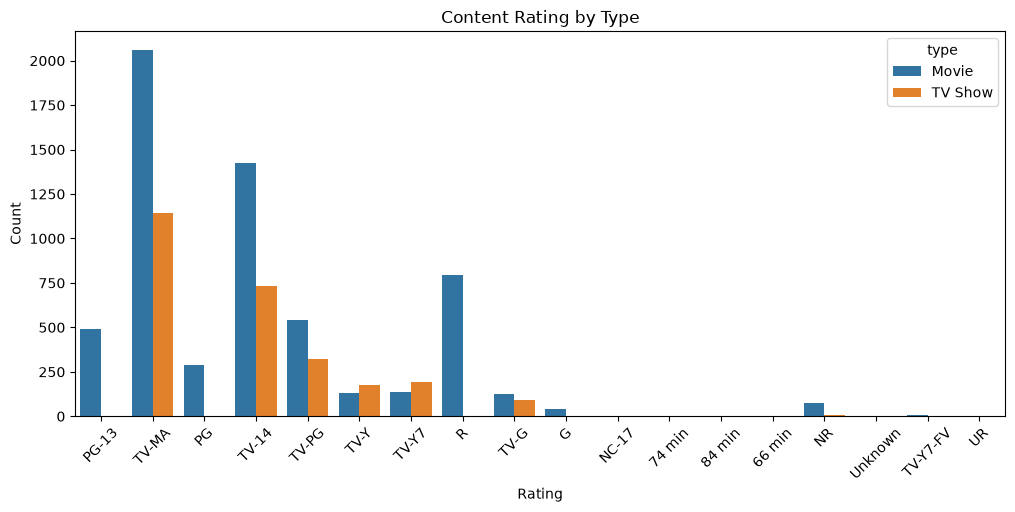

In [74]:
# Bivariate Analysis: Content Type vs Rating

plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x="rating",
    hue="type"
)

plt.title("Content Rating by Type")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

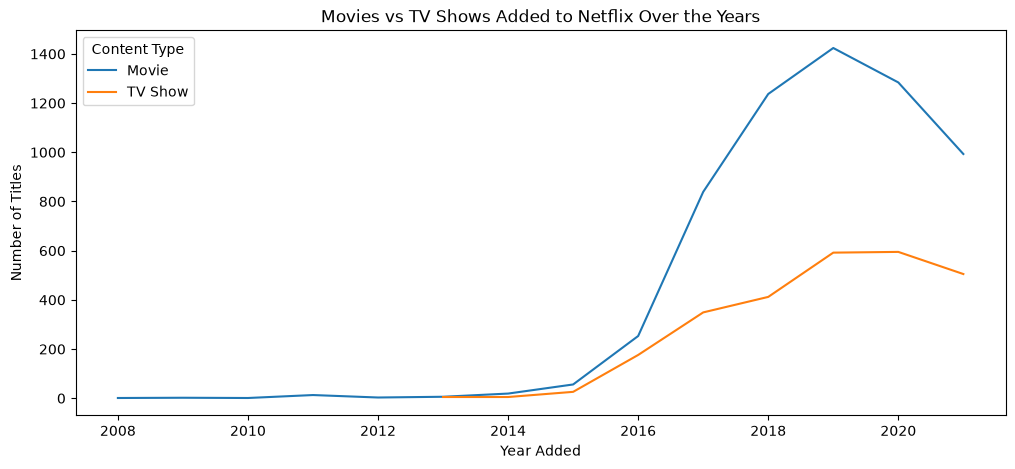

In [77]:
# Bivariate Analysis: Content Type vs Year Added

year_type = df.groupby(["year_added", "type"]).size().unstack()

year_type.plot(
    kind="line",
    figsize=(12, 5)
)

plt.title("Movies vs TV Shows Added to Netflix Over the Years")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.legend(title="Content Type")
plt.show()

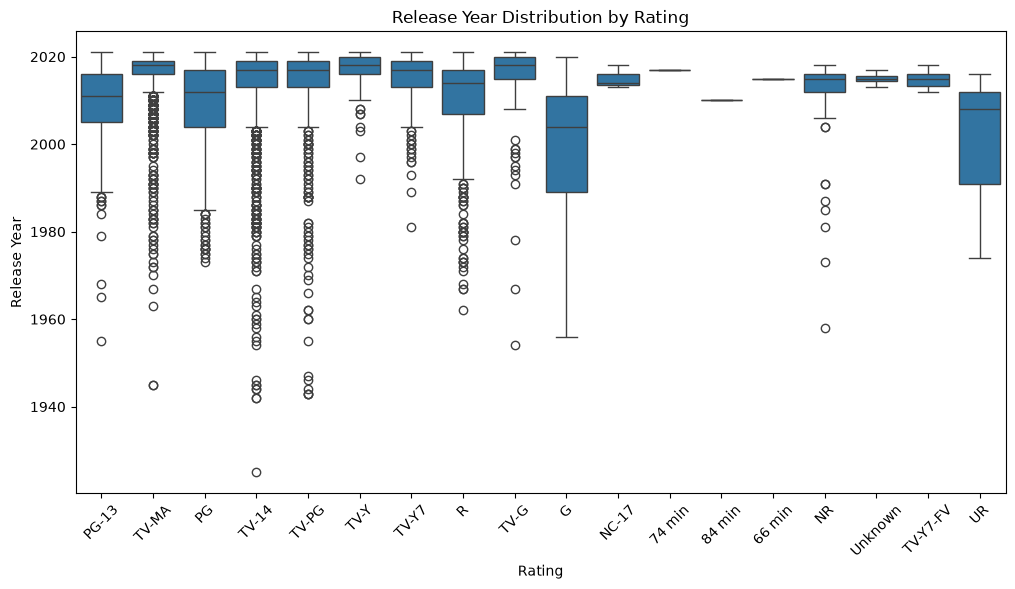

In [78]:
# Bivariate Analysis: Release Year vs Rating

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="rating",
    y="release_year"
)

plt.title("Release Year Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Release Year")
plt.xticks(rotation=45)
plt.show()

## 10. Multivariate Analysis

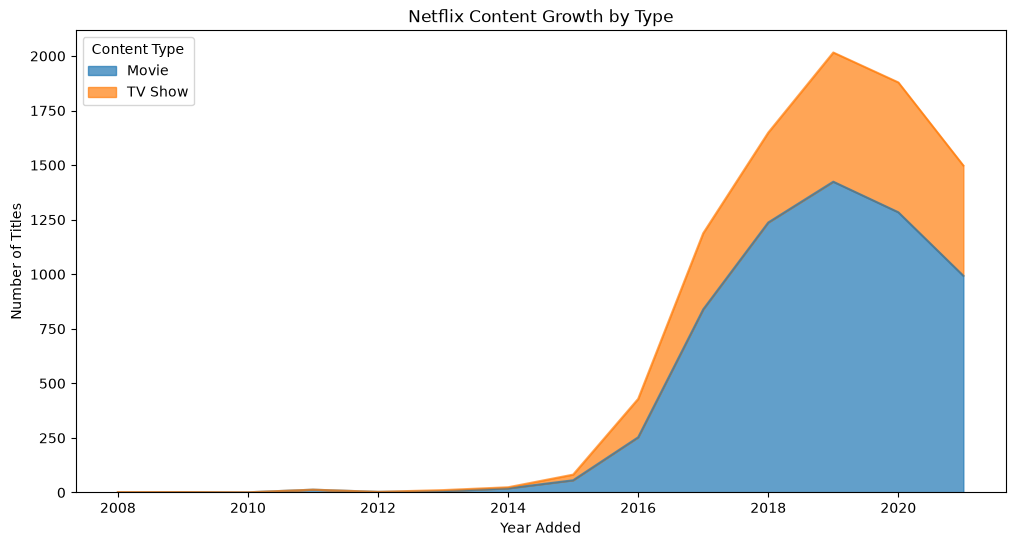

In [79]:
# Multivariate Analysis: Type, Year Added and Count

content_trend = df.groupby(
    ["year_added", "type"]
).size().unstack()

content_trend.plot(
    kind="area",
    figsize=(12, 6),
    alpha=0.7
)

plt.title("Netflix Content Growth by Type")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.legend(title="Content Type")
plt.show()

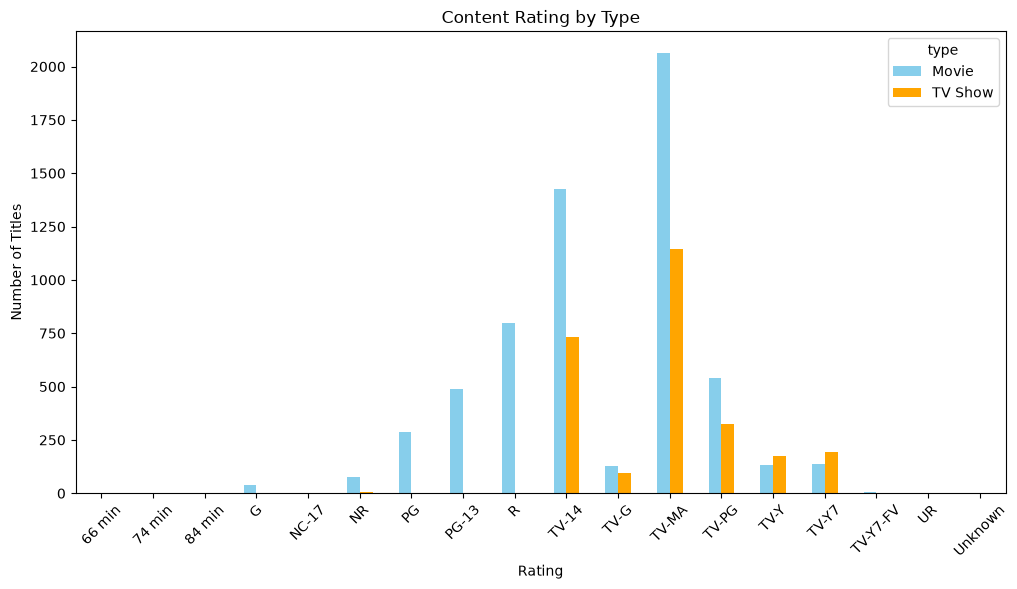

In [82]:
# Multivariate Analysis: Rating, Type and Count

rating_type = pd.crosstab(
    df["rating"],
    df["type"]
)

rating_type.plot(
    kind="bar",
    figsize=(12, 6),
    color=["skyblue", "orange"]
)

plt.title("Content Rating by Type")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

In [84]:
# Multivariate Analysis: Year, Month and Content Type

monthly_content = df.groupby(
    ["year_added", "month_added", "type"]
).size().reset_index(name="count")

print(monthly_content.head(10))

   year_added  month_added     type  count
0      2008.0          1.0    Movie      1
1      2008.0          2.0  TV Show      1
2      2009.0          5.0    Movie      1
3      2009.0         11.0    Movie      1
4      2010.0         11.0    Movie      1
5      2011.0          5.0    Movie      1
6      2011.0          9.0    Movie      1
7      2011.0         10.0    Movie     11
8      2012.0          2.0    Movie      1
9      2012.0         11.0    Movie      1


## 11. Time-Based Analysis

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64


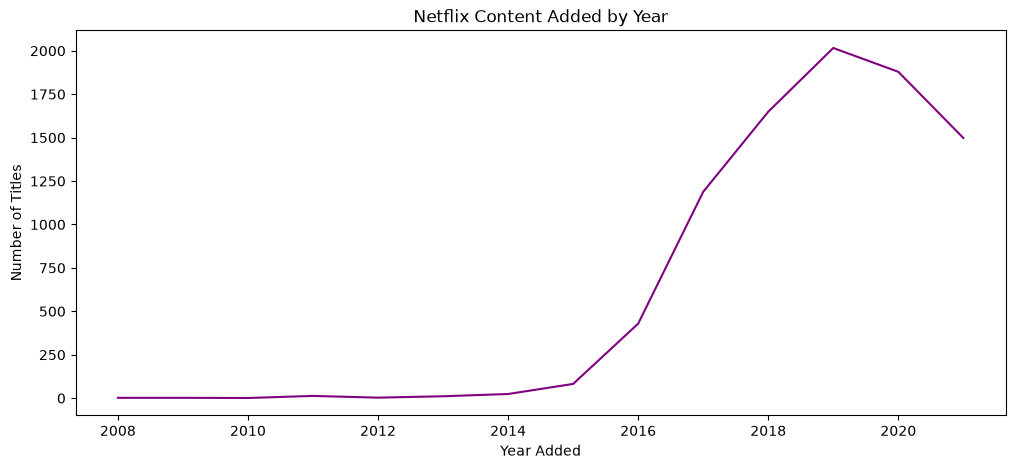

In [88]:
# Time-Based Analysis: Content Added by Year

yearly_additions = df["year_added"].value_counts().sort_index()

print(yearly_additions)

yearly_additions.plot(
    kind="line",
    figsize=(12, 5),
    color="purple"
)

plt.title("Netflix Content Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()

month_added
1.0     738
2.0     563
3.0     742
4.0     764
5.0     632
6.0     728
7.0     827
8.0     755
9.0     770
10.0    760
11.0    705
12.0    813
Name: count, dtype: int64


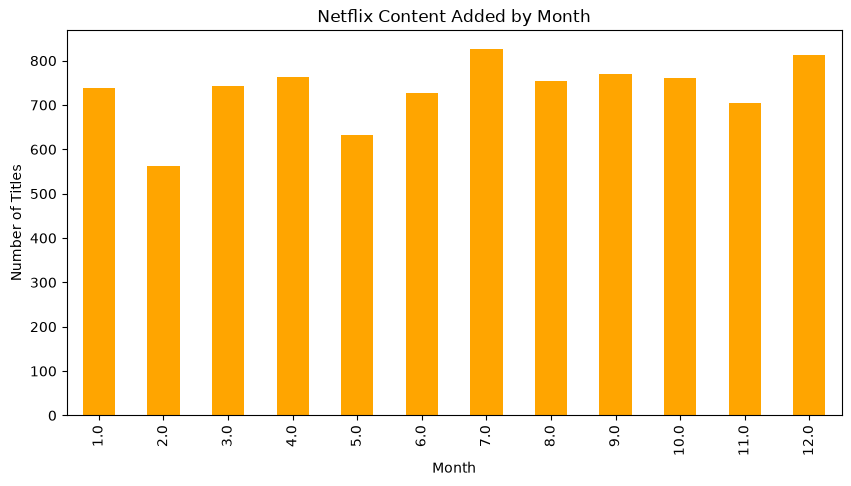

In [89]:
# Time-Based Analysis: Content Added by Month

monthly_additions = df["month_added"].value_counts().sort_index()

print(monthly_additions)

monthly_additions.plot(
    kind="bar",
    figsize=(10, 5),
    color="orange"
)

plt.title("Netflix Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")
plt.show()

## 12. Key Insights

### 1. Content Type
- Netflix's catalog contains both Movies and TV Shows, with Movies forming the larger share of the dataset.

### 2. Content Ratings
- The rating distribution shows that Netflix has content across multiple audience categories.
- Some ratings are significantly more common than others.

### 3. Release Year
- The dataset contains content released across a wide range of years.
- The distribution is concentrated more heavily toward recent release years.

### 4. Content Type and Release Year
- Movies and TV Shows show different release-year distributions.
- This indicates differences in the composition of Netflix's movie and TV catalog.

### 5. Content Added Over Time
- Netflix's content additions vary across years.
- The year-wise trend helps identify periods of higher and lower content additions.

### 6. Monthly Content Addition
- The number of titles added varies across months.
- This shows that Netflix does not add the same amount of content every month.

## 13. Final Conclusion

This exploratory data analysis provided a comprehensive understanding of the Netflix content library.

The analysis examined content types, ratings, release years, relationships between different variables, and content addition trends over time.

The findings provide useful insights into Netflix's content distribution and growth patterns and form a strong foundation for building an interactive Netflix Content Intelligence dashboard.